In [1]:
import pandas as pd

X_train = pd.read_csv("Data/train_input_Z61KlZo.csv")
y_train = pd.read_csv("Data/train_output_DzPxaPY.csv")
X_test = pd.read_csv("Data/test_input_5qJzHrr.csv")
y_pred_random = pd.read_csv("Data/test_output_random.csv")

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

C:\Users\ilyes\AppData\Local\Temp\ipykernel_8496\461888069.py:3: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv("Data/train_input_Z61KlZo.csv")
C:\Users\ilyes\AppData\Local\Temp\ipykernel_8496\461888069.py:5: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test = pd.read_csv("Data/test_input_5qJzHrr.csv")


Train: (383610, 374)
Test: (95852, 374)


In [2]:
from sklearn.model_selection import train_test_split

X_train_train, X_train_test, y_train_train, y_train_test = train_test_split(X_train, y_train, test_size=X_test.shape[0], random_state=42)

In [3]:
from sklearn.metrics import root_mean_squared_error

def rmse(y1, y2):
    return round(root_mean_squared_error(y1['CHARGE'], y2['CHARGE']), 2)

# Preprocessing

In [6]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

def preprocessing(X_train, X_test):
    # Save ID columns
    train_ids = X_train['ID']
    test_ids = X_test['ID']

    # separate columns + remove 'ID'
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    num_cols.remove('ID')
    cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    # reduce size
    X_train[num_cols] = X_train[num_cols].astype("float32")
    X_test[num_cols] = X_test[num_cols].astype("float32")

    # mixed types -> strings only
    X_train[cat_cols] = X_train[cat_cols].astype(str)
    X_test[cat_cols] = X_test[cat_cols].astype(str)

    # pipelines
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

    # fit transform
    X_train_clean = preprocessor.fit_transform(X_train)
    X_test_clean = preprocessor.transform(X_test)

    # Feature names
    all_features = num_cols + cat_cols

    # dataframes
    X_train_clean = pd.DataFrame(X_train_clean, columns=all_features, index=train_ids)
    X_test_clean = pd.DataFrame(X_test_clean, columns=all_features, index=test_ids)

    return X_train_clean, X_test_clean

In [7]:
# X_train_train_clean, X_train_test_clean = preprocessing(X_train_train, X_train_test)

# X_train_train_clean.to_csv('Data/X_train_train_clean.csv')
# X_train_test_clean.to_csv('Data/X_train_test_clean.csv')

import pandas as pd

X_train_train_clean = pd.read_csv('Data/X_train_train_clean.csv', index_col='ID')
X_train_test_clean = pd.read_csv('Data/X_train_test_clean.csv', index_col='ID')

# Random

In [17]:
import numpy as np

# local
y_train_pred_random = y_train_test.copy()
y_train_pred_random['CHARGE'] = np.random.choice(y_train_train['CHARGE'], size=len(y_train_test))

rmse(y_train_test, y_train_pred_random)

10177.2

# Zero

In [18]:
# local
y_train_pred_zero = y_train_test.copy()
y_train_pred_zero['CHARGE'] = 0

rmse(y_train_test, y_train_pred_zero)

6837.83

# Lasso

In [8]:
from sklearn.linear_model import Lasso

y_train_pred_lasso = y_train_test.copy()

target = 'CHARGE'
y_train_col = y_train_train[target]
model = Lasso(alpha=1.0, random_state=42)  # You can tune alpha as needed
model.fit(X_train_train_clean, y_train_col)
preds = model.predict(X_train_test_clean)
y_train_pred_lasso[target] = preds

rmse(y_train_test, y_train_pred_lasso)

c:\Users\ilyes\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.610e+12, tolerance: 1.326e+09
  model = cd_fast.enet_coordinate_descent(


6835.93

# Decision Trees

In [9]:
from sklearn.tree import DecisionTreeRegressor

y_train_pred_dts = y_train_test.copy()

targets = ['FREQ', 'CM', 'ANNEE_ASSURANCE']

for target in targets:
    y_train_col = y_train_train[target]
    model = DecisionTreeRegressor(max_depth=5, random_state=42)
    model.fit(X_train_train_clean, y_train_col)
    preds = model.predict(X_train_test_clean)
    y_train_pred_dts[target] = preds

y_train_pred_dts['CHARGE'] = y_train_pred_dts['FREQ'] * y_train_pred_dts['CM'] * y_train_pred_dts['ANNEE_ASSURANCE']

rmse(y_train_test, y_train_pred_dts)

6837.59

# Decision Tree

In [10]:
from sklearn.tree import DecisionTreeRegressor

y_train_pred_dt = y_train_test.copy()

target = 'CHARGE'
y_train_col = y_train_train[target]
model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train_train_clean, y_train_col)
preds = model.predict(X_train_test_clean)
y_train_pred_dt[target] = preds

rmse(y_train_test, y_train_pred_dt)

6860.92

# Hybrid Decision Tree

In [11]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

def hdt(X_train_train_clean, X_train_test_clean, y_train_train, y_train_test):
    y_train_train = y_train_train.set_index('ID').copy()
    y_train_test = y_train_test.set_index('ID').copy()

    target = 'CHARGE'

    # Step 1: Binary version of the target
    y_train_target = y_train_train[[target]]
    y_train_binary = (y_train_target != 0).astype(int)

    # Step 2: Train Decision Tree Classifier
    clf = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_train_train_clean, y_train_binary)

    # Step 3: Predict binary labels for test set
    binary_preds = clf.predict(X_train_test_clean)

    # Step 4: Train Regressor on data where target != 0
    non_zero_indices = y_train_binary[y_train_binary == 1].index
    reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    reg.fit(X_train_train_clean.loc[non_zero_indices], y_train_target.loc[non_zero_indices])

    # Step 5: Initialize predictions
    y_train_pred_hdt = y_train_test.copy()
    y_train_pred_hdt[target] = 0  # default prediction is 0

    # Step 6: Apply regression only where classifier predicted 1
    test_non_zero_indices = X_train_test_clean.index[binary_preds == 1]
    y_train_pred_hdt.loc[test_non_zero_indices, target] = reg.predict(X_train_test_clean.loc[test_non_zero_indices])

    return y_train_pred_hdt.reset_index()

In [12]:
y_train_pred_hdt = hdt(X_train_train_clean, X_train_test_clean, y_train_train, y_train_test)

rmse(y_train_test, y_train_pred_hdt)

C:\Users\ilyes\AppData\Local\Temp\ipykernel_8496\1326595458.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[763.20748232 763.20748232  10.52631579]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  y_train_pred_hdt.loc[test_non_zero_indices, target] = reg.predict(X_train_test_clean.loc[test_non_zero_indices])


6837.74

# Random Forest

In [13]:
from sklearn.ensemble import RandomForestRegressor

y_train_pred_rf = y_train_test.copy()

target = 'CHARGE'
y_train_col = y_train_train[target]
model = RandomForestRegressor(max_depth=5, random_state=42)
model.fit(X_train_train_clean, y_train_col)
preds = model.predict(X_train_test_clean)
y_train_pred_rf[target] = preds

rmse(y_train_test, y_train_pred_rf)

6856.2

# Decision Tree & Random Forest

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor  # updated import

def dtrf(X_train_train_clean, X_train_test_clean, y_train_train, y_train_test):
    y_train_train = y_train_train.set_index('ID').copy()
    y_train_test = y_train_test.set_index('ID').copy()

    target = 'CHARGE'

    # Step 1: Binary version of the target
    y_train_target = y_train_train[[target]]
    y_train_binary = (y_train_target != 0).astype(int)

    # Step 2: Train Decision Tree Classifier
    clf = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_train_train_clean, y_train_binary)

    # Step 3: Predict binary labels for test set
    binary_preds = clf.predict(X_train_test_clean)

    # Step 4: Train Random Forest Regressor on data where target != 0
    non_zero_indices = y_train_binary[y_train_binary == 1].index
    reg = RandomForestRegressor(max_depth=5, random_state=42)
    reg.fit(X_train_train_clean.loc[non_zero_indices], y_train_target.loc[non_zero_indices].values.ravel())

    # Step 5: Initialize predictions
    y_train_pred_dtrf = y_train_test.copy()
    y_train_pred_dtrf[target] = 0  # default prediction is 0

    # Step 6: Apply regression only where classifier predicted 1
    test_non_zero_indices = X_train_test_clean.index[binary_preds == 1]
    y_train_pred_dtrf.loc[test_non_zero_indices, target] = reg.predict(X_train_test_clean.loc[test_non_zero_indices])

    return y_train_pred_dtrf.reset_index()

In [15]:
y_train_pred_dtrf = dtrf(X_train_train_clean, X_train_test_clean, y_train_train, y_train_test)

rmse(y_train_test, y_train_pred_dtrf)

C:\Users\ilyes\AppData\Local\Temp\ipykernel_8496\1653747090.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 663.81406883  643.93363301 1148.93123092]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  y_train_pred_dtrf.loc[test_non_zero_indices, target] = reg.predict(X_train_test_clean.loc[test_non_zero_indices])


6837.75

# Compare Models

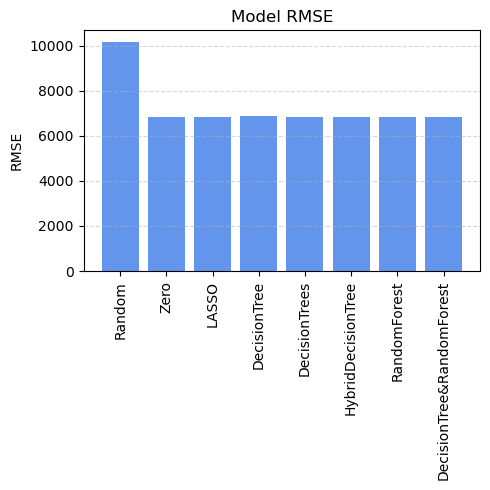

In [21]:
import matplotlib.pyplot as plt

train_pred_dict = {
    'Random': y_train_pred_random,
    'Zero': y_train_pred_zero,
    'LASSO': y_train_pred_lasso,
    'DecisionTree': y_train_pred_dt,
    'DecisionTrees': y_train_pred_dts,
    'HybridDecisionTree': y_train_pred_hdt,
    'RandomForest': y_train_pred_rf,
    'DecisionTree&RandomForest': y_train_pred_dtrf,
}

rmse_scores = {name: rmse(y_train_test, pred) for name, pred in train_pred_dict.items()}

plt.figure(figsize=(5, 5))
plt.bar(rmse_scores.keys(), rmse_scores.values(), color='cornflowerblue')
plt.ylabel('RMSE')
plt.title('Model RMSE')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

| Model                       | RMSE    |
|----------------------------|---------|
| Random                     | 10177.2 |
| Zero                       | 6837.83 |
| LASSO                      | 6835.93 |
| Decision Tree              | 6860.92 |
| Decision Trees             | 6837.59 |
| HybridDecisionTree         | 6837.74 |
| RandomForest               | 6856.2  |
| DecisionTree&RandomForest  | 6837.75 |